______________________________________
## Credit Card Fraud Detector
______________________________

In [1]:
# Gathering Environment

import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE

In [2]:
# Loading Dataset

df = pd.read_csv('../Data/creditcard.csv')
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
128870,78869.0,1.323202,0.225009,0.155145,0.330271,-0.058350,-0.516958,0.055024,-0.171447,0.070586,...,-0.312946,-0.888286,0.033890,-0.433642,0.317156,0.250603,-0.036425,0.009779,2.50,0
55041,46743.0,-1.161484,0.456914,1.536232,-0.115453,0.336070,0.529350,1.186612,0.308299,-0.853946,...,0.264704,0.406843,-0.001417,-0.332758,0.543918,-0.372081,-0.000753,0.054306,149.00,0
169049,119498.0,1.940688,-0.500676,-0.322131,0.275600,-0.514027,0.213673,-0.806043,0.191394,0.950283,...,0.219097,0.796627,0.193393,0.769029,-0.303224,0.517234,-0.023288,-0.049207,11.50,0
271138,164427.0,-0.037375,0.007143,1.026410,-0.031601,-0.102972,-0.615820,0.036948,0.019071,0.779444,...,0.402267,1.268701,0.030431,0.078526,-0.662070,-0.212545,0.169718,0.130284,34.90,0
252059,155633.0,-0.649994,0.846350,0.891532,-1.508643,1.024153,-1.108678,1.699969,-0.703318,0.312043,...,-0.319611,-0.538024,-0.116712,-0.049498,-0.362881,-0.101791,-0.298070,-0.224106,11.48,0


In [3]:
# Difinig Features and Target Column

X = df.drop(columns='Class')
Y = df['Class']

In [4]:
# Spliting data into training and testing
 
X_Train,X_Test,Y_Train,Y_Test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [5]:
# Applying SMOTE

smote = SMOTE(random_state=42)

X_Train_SMOTE, Y_Train_SMOTE = smote.fit_resample(
    X_Train, Y_Train
)

print("Before SMOTE :",Y_Train.value_counts())
print("After SMOTE :",Y_Train_SMOTE.value_counts())

Before SMOTE : Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE : Class
0    227451
1    227451
Name: count, dtype: int64


In [6]:
rf = RandomForestClassifier(n_estimators=50,random_state=42)
rf.fit(X_Train,Y_Train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [7]:
Y_pred = rf.predict(X_Test)

In [8]:
accuracy = accuracy_score(Y_Test, Y_pred)
print(accuracy)

0.9995435553526912


<Figure size 600x500 with 0 Axes>

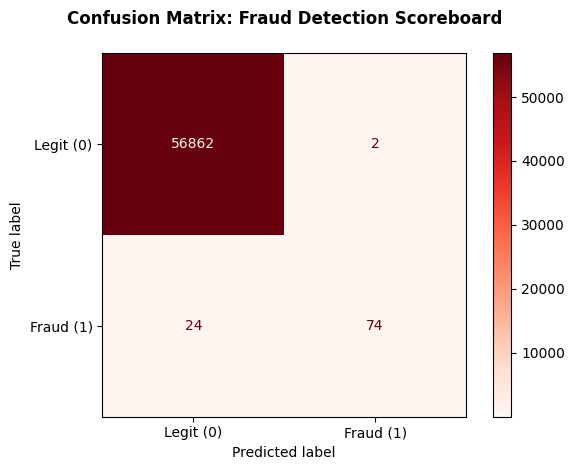

In [9]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(Y_Test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Fraud (1)'])

# Using 'Reds' or 'Blues' to emphasize the contrast
disp.plot(cmap='Reds', values_format='d')  
plt.title('Confusion Matrix: Fraud Detection Scoreboard\n', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Precision Score

print(f"Precision Score: {precision_score(Y_Test, Y_pred):.4f}")

Precision Score: 0.9737


In [16]:
# Recall Score

print(f"Recall Score:    {recall_score(Y_Test, Y_pred):.4f}")

Recall Score:    0.7551


In [18]:
# F-1 Score

print(f"F1-Score:        {f1_score(Y_Test, Y_pred):.4f}")

F1-Score:        0.8506


In [19]:
# ROC and AUC Curve

y_pred = rf.predict(X_Test)
y_probs = rf.predict_proba(X_Test)[:, 1]

y_probs

array([0.98, 0.  , 0.  , ..., 0.  , 0.  , 0.  ], shape=(56962,))

In [20]:
print(f"ROC-AUC Score:   {roc_auc_score(Y_Test, y_probs):.4f}")

ROC-AUC Score:   0.9481
